In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
import seaborn as sns
from seaborn import kdeplot
import numpy as np
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from evo_sim import evo_sim
from simulators import wrapper
from inference_utils import get_prior
from seaborn import histplot
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400

import warnings
warnings.simplefilter('ignore', Warning)

prior = get_prior('EVO_SIM')

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize
    matplotlib.rcParams['axes.labelsize'] = fontsize
    matplotlib.rcParams['legend.fontsize'] = fontsize


def EVO_SIM_wrapper(reps, parameters, seed=None):
    evo_reps = torch.empty(reps, 30)
    for i in range(reps):
        out=evo_sim(parameters)
        evo_reps[i,:] = torch.tensor(out)
    return evo_reps


In [30]:
def plot_vec30(
    vec30: np.ndarray,
    sample_every: int = 100,
    gens: int = 1000,
    order: str = "blocked",  # "blocked" = [10 for mut1][10 for mut2][10 for mut3]
                              # "interleaved" = [mut1_t100,mut2_t100,mut3_t100, mut1_t200,...]
    labels = ("Mutation 1", "Mutation 2", "Mutation 3"),
    title: str = "Three mutations (allele frequencies)",
    ax = None
):
    vec30 = np.asarray(vec30, dtype=float)
    if vec30.shape != (30,):
        raise ValueError(f"vec30 must have shape (30,), got {vec30.shape}")

    times = np.arange(sample_every, gens + 1, sample_every)  # 100..1000 (10 points)

    if order == "blocked":
        f1, f2, f3 = vec30[:10], vec30[10:20], vec30[20:30]
    elif order == "interleaved":
        # reshape to [10,3] with columns = (mut1,mut2,mut3)
        F = vec30.reshape(10, 3)
        f1, f2, f3 = F[:, 0], F[:, 1], F[:, 2]
    else:
        raise ValueError('order must be "blocked" or "interleaved"')

    ax.plot(times, f1, label=labels[0], color='red')
    ax.plot(times, f2, label=labels[1], color='blue', ls='--')
    ax.plot(times, f3, label=labels[2], color='green', ls=':')
    ax.set_xlabel("Generation")
    ax.set_ylabel("Allele frequency")
    ax.set_title(title)
    plt.tight_layout()



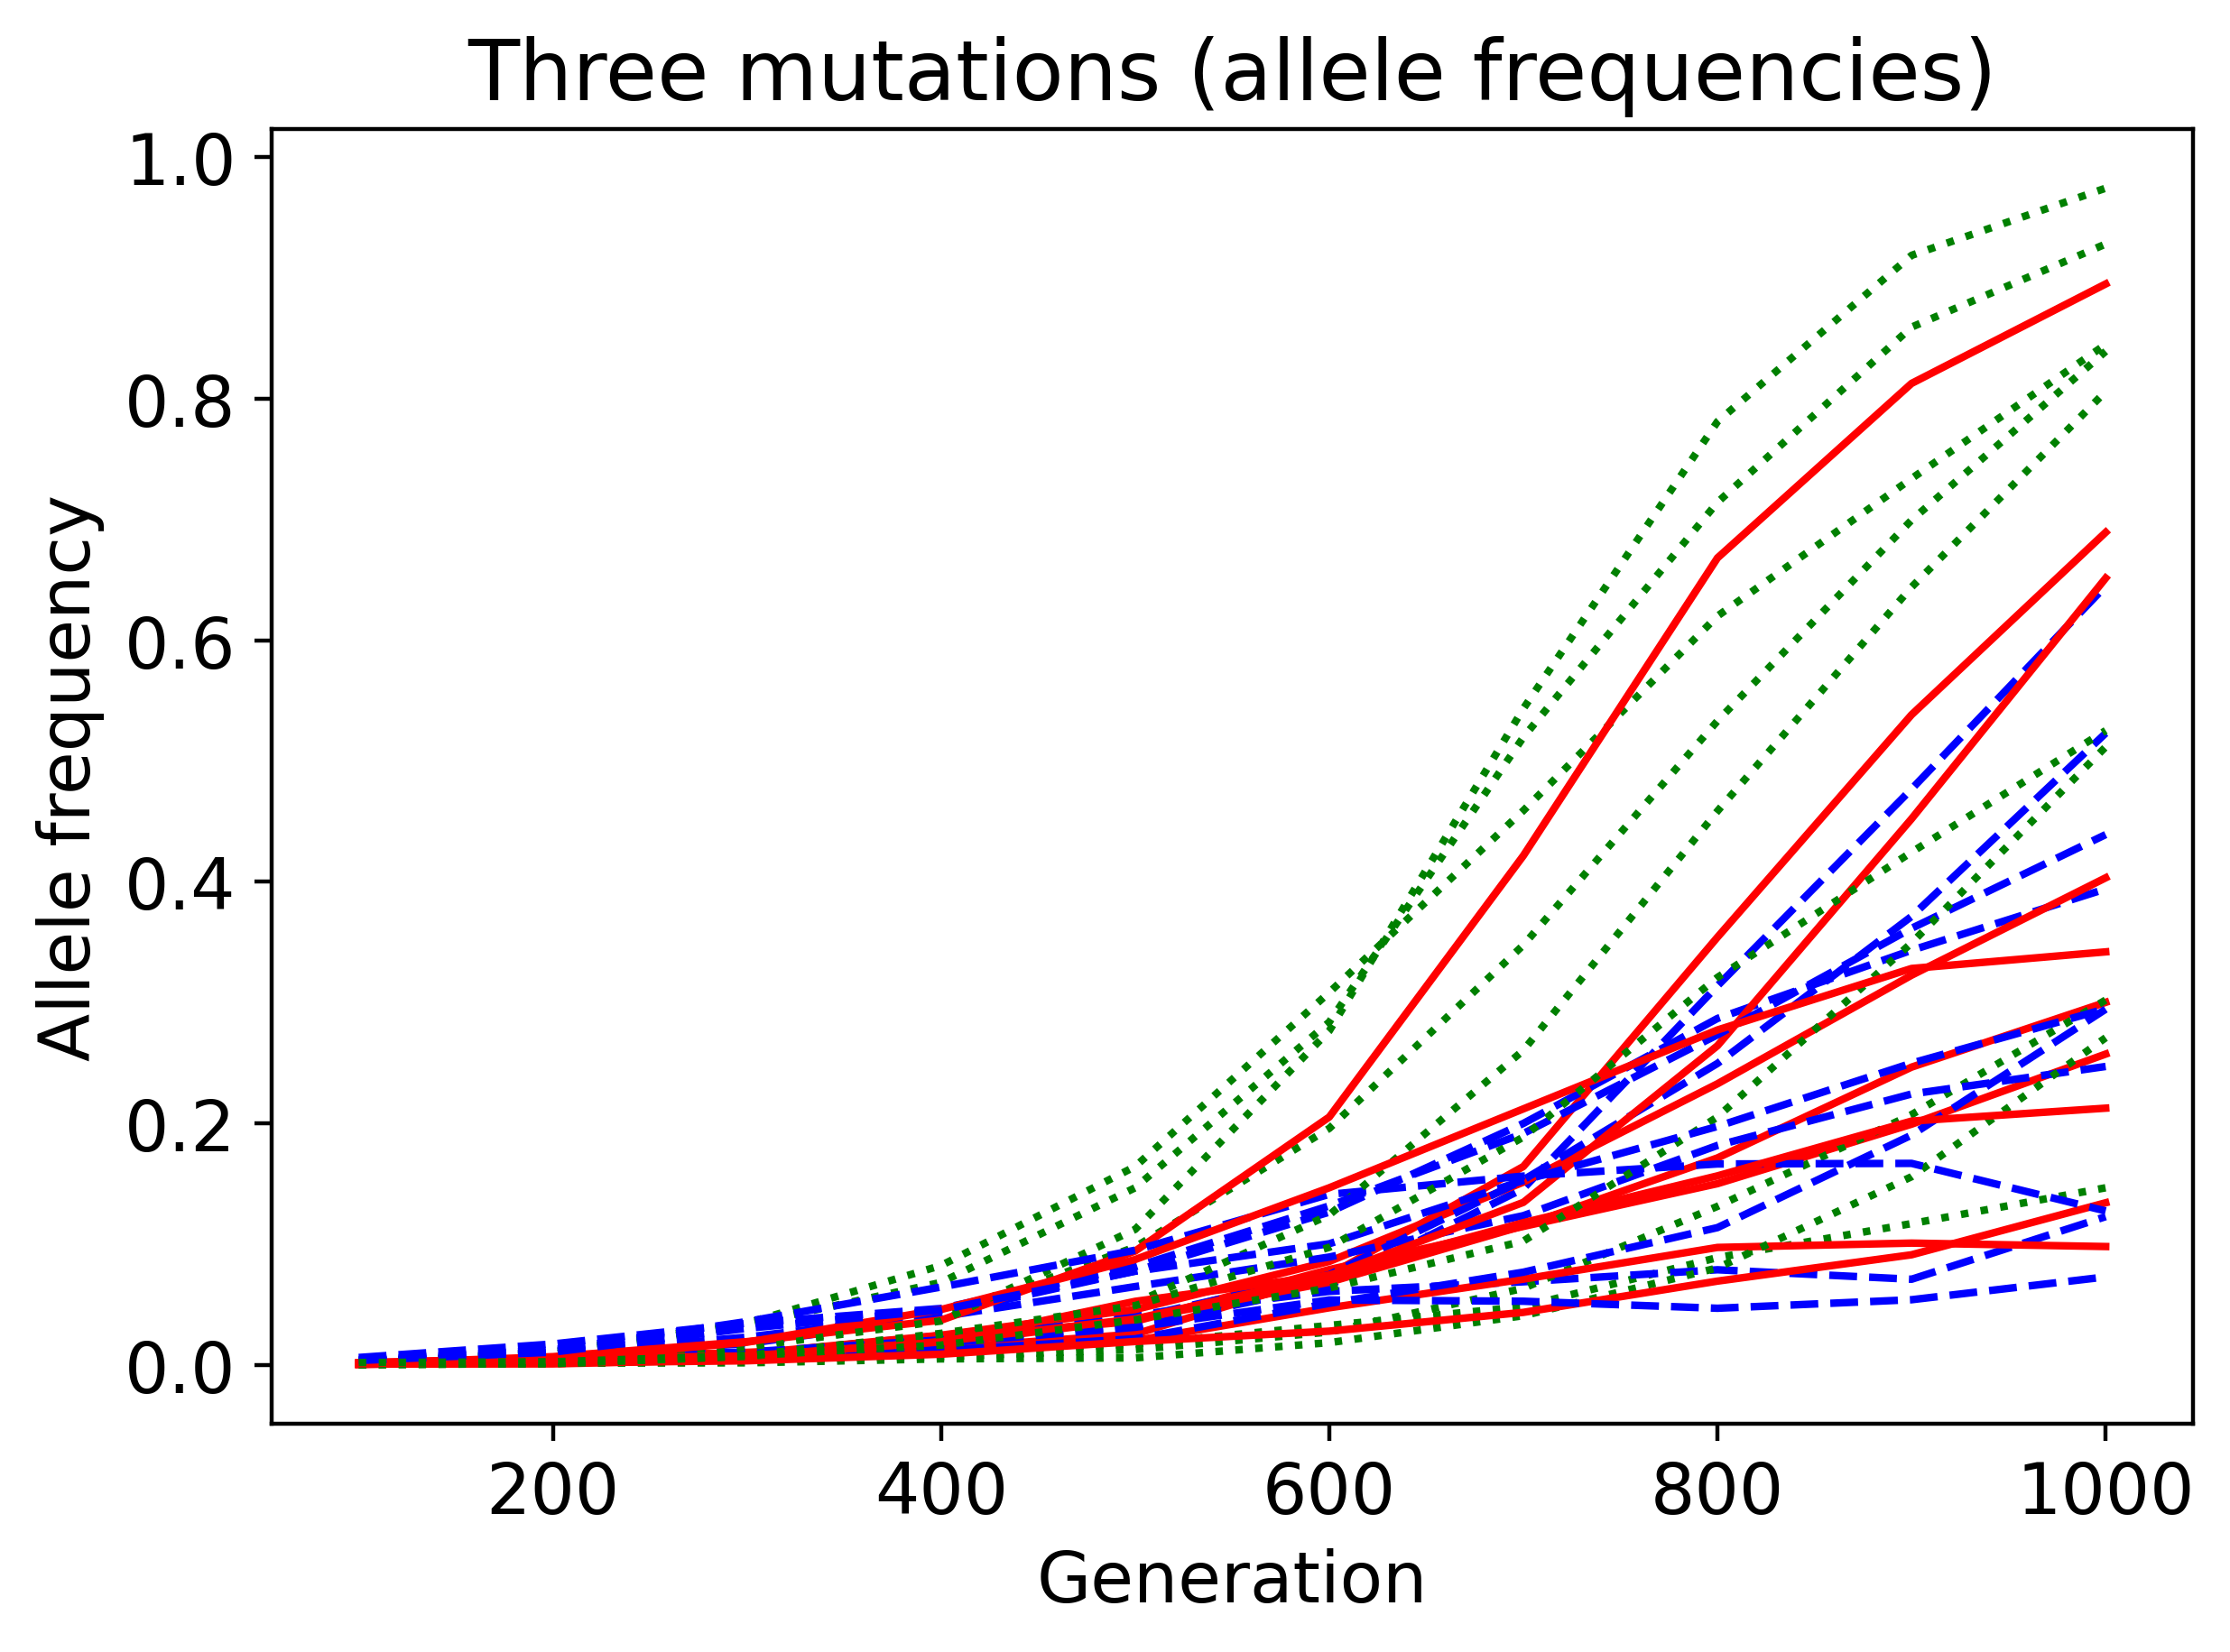

In [31]:
th = prior.sample((1,))[0]
X = EVO_SIM_wrapper(reps=10, parameters=th)
fig, ax = plt.subplots()
for i in range(len(X)):
    plot_vec30(X[i], ax=ax)

MCMC from top SN: 100%|██████████| 300/300 [00:03<00:00, 58.54it/s]


Drawing 300 posterior samples:   0%|          | 0/300 [00:00<?, ?it/s]

MCMC from top SN: 100%|██████████| 300/300 [00:03<00:00, 60.02it/s]


Drawing 300 posterior samples:   0%|          | 0/300 [00:00<?, ?it/s]

MCMC from top SN: 100%|██████████| 300/300 [00:03<00:00, 60.53it/s]


Drawing 300 posterior samples:   0%|          | 0/300 [00:00<?, ?it/s]

MCMC from top SN: 100%|██████████| 300/300 [00:03<00:00, 60.80it/s]


Drawing 300 posterior samples:   0%|          | 0/300 [00:00<?, ?it/s]

MCMC from top SN: 100%|██████████| 300/300 [00:03<00:00, 60.67it/s]


Drawing 300 posterior samples:   0%|          | 0/300 [00:00<?, ?it/s]

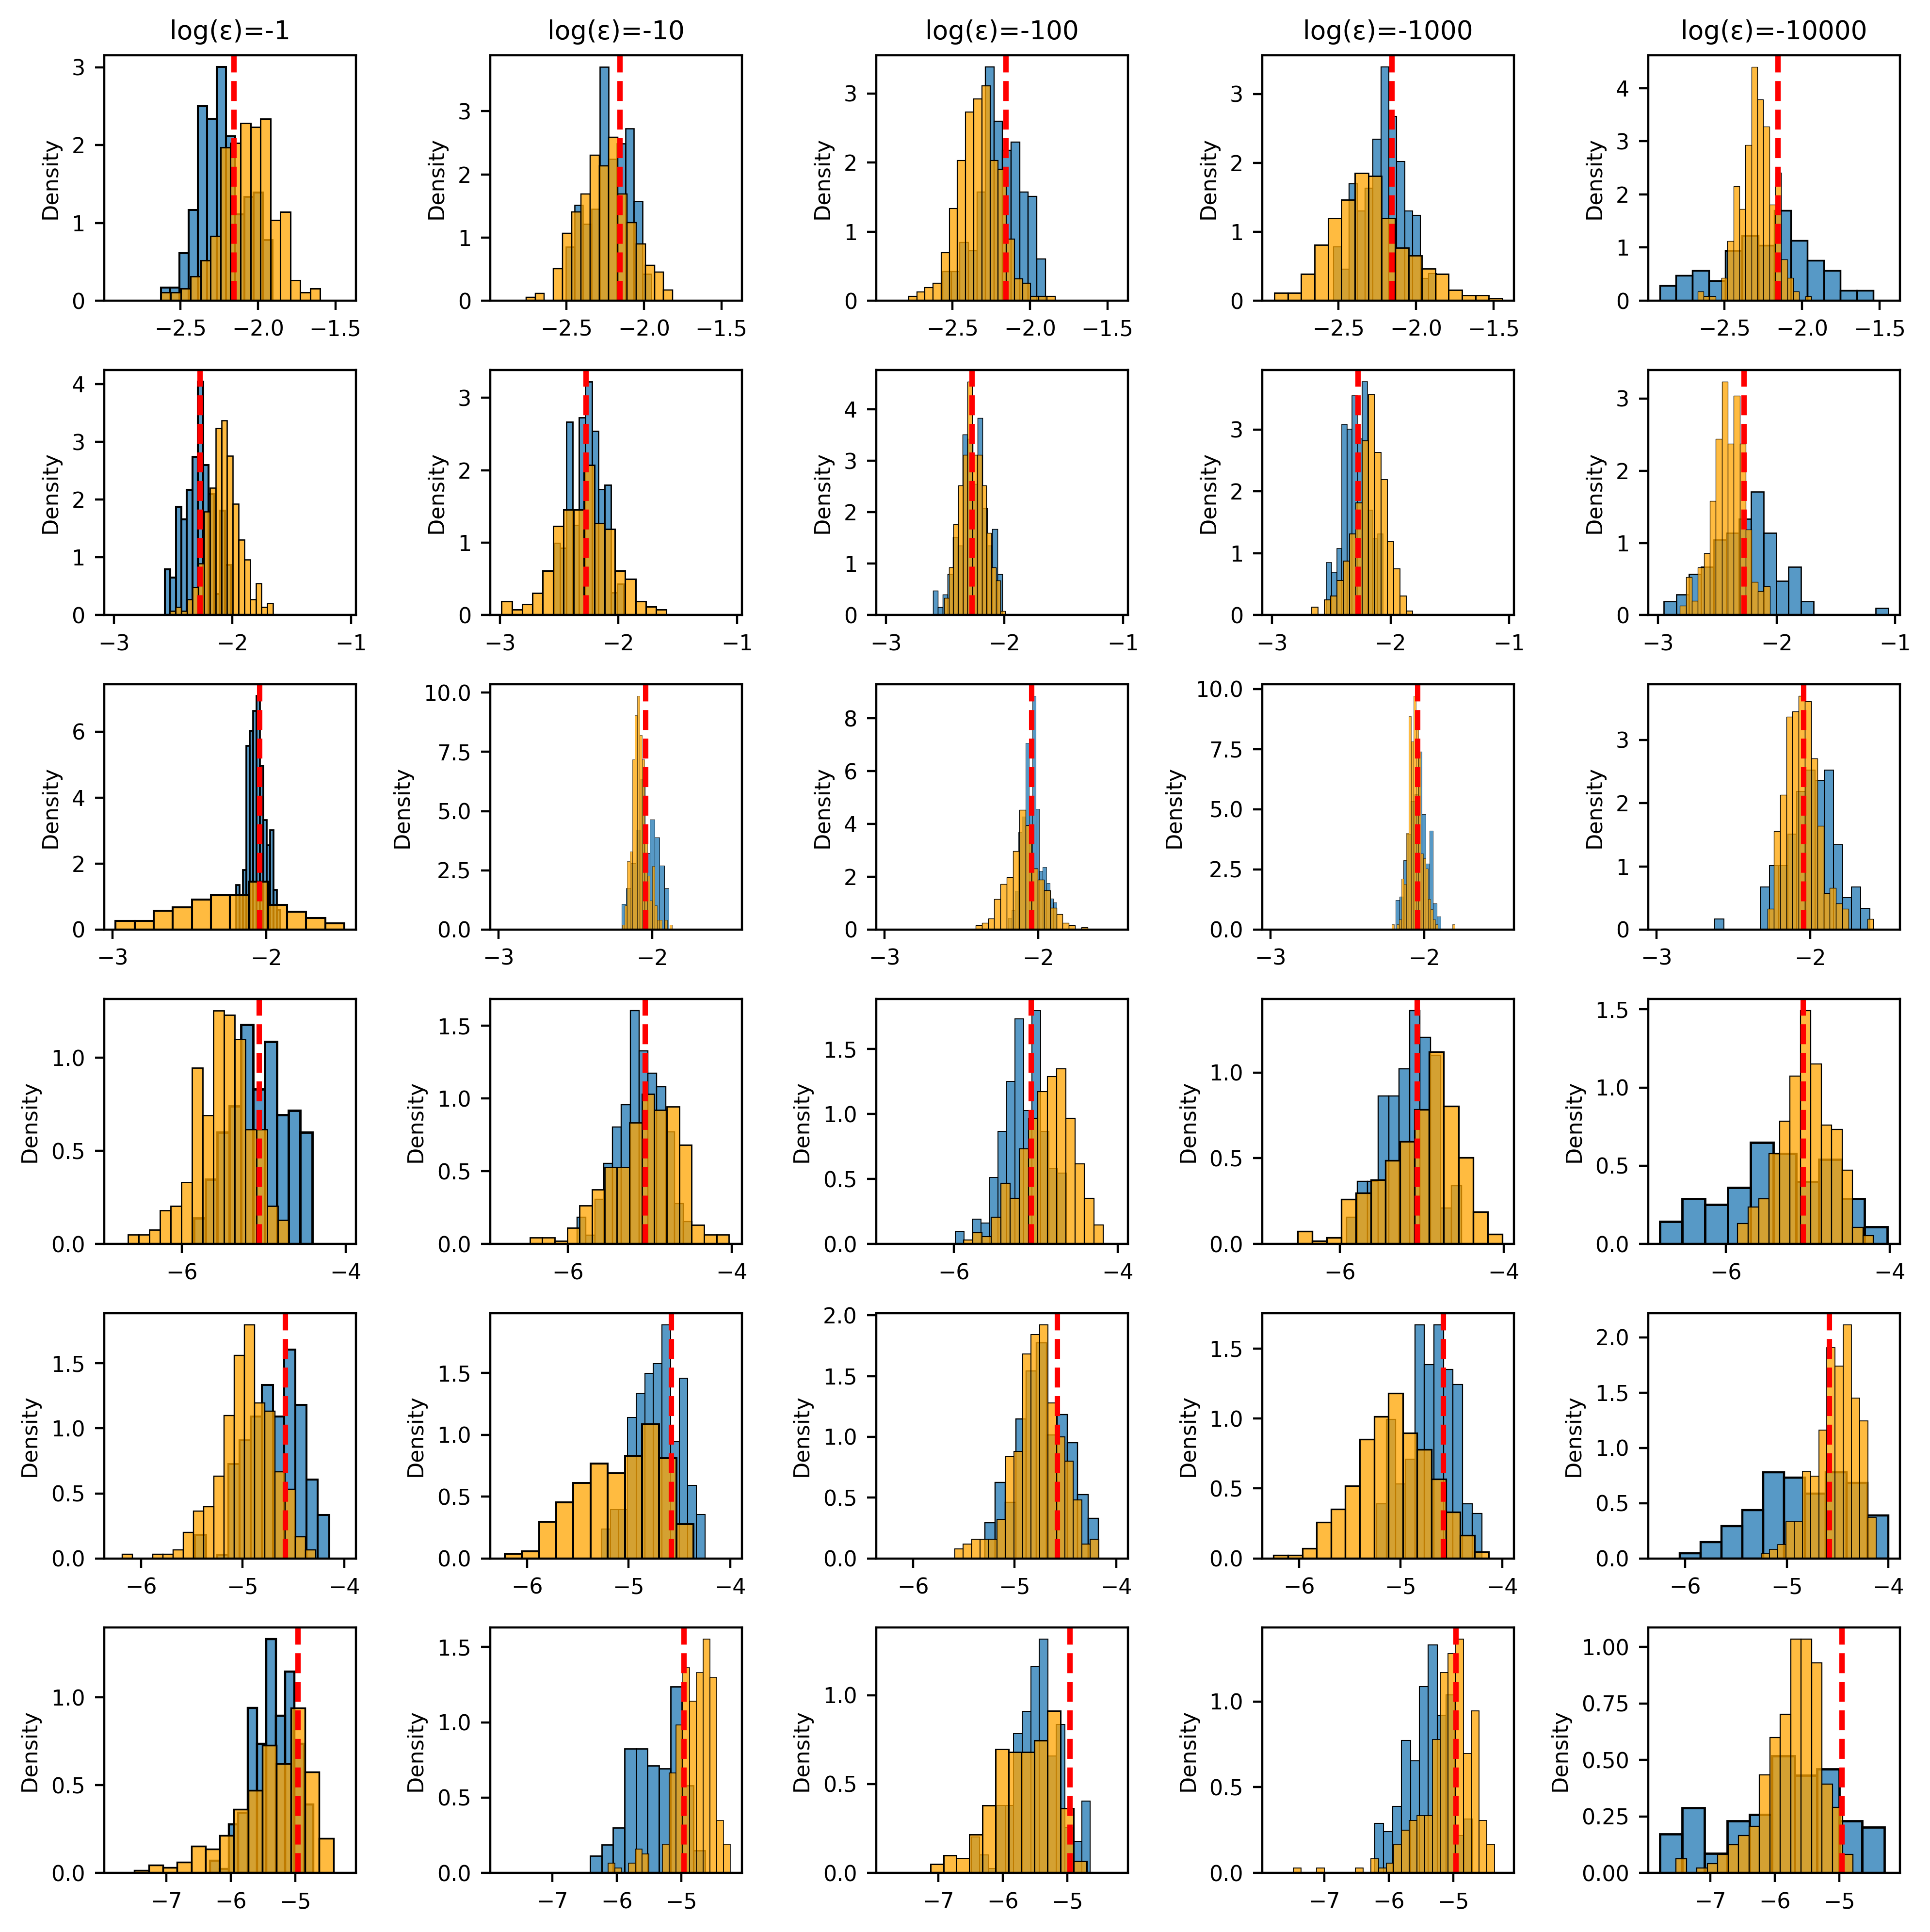

In [36]:
change_font(8)
fig, ax = plt.subplots(6,5, tight_layout=True, figsize=(10,10), sharex='row')

posterior = pickle.load(open('posterior_EVO_SIM_30000_20.pkl', 'rb'))
for i in range(5):
    epsilon = -10**i
    ax[0,i].set_title(f'log(ε)={int(epsilon)}')
    op = CollectivePosterior(prior, X, posterior, 1, epsilon)
    op.get_log_C()
    samps = op.mcmc_from_top_sn(300)
    samples = posterior.set_default_x(X[i]).sample((300,))

    for j in range(len(samps[0])):
        histplot(samps[:,j], ax=ax[j,i], stat='density')
        histplot(samples[:,j], ax=ax[j,i], stat='density', color='orange')
        ax[j,i].axvline(th[j], color='red', lw=2, ls='--')